In [407]:
import pandas as pd
import json

In [ ]:
study_files = {
    "ablation_bs" : "output/hyperparameter_studies/ablation_bs_new/study_ViT-B16_resnet50-GN_20260504_011514.json"
}

In [415]:

study_files = {
    "IC_default": "output/hyperparameter_studies/imagenetc_default_new/study_ViT-B16_resnet50-GN_20260503_145722.json",
    "IC_label": "output/hyperparameter_studies/imagenetc_label_new/study_ViT-B16_resnet50-GN_20260502_205737.json",
    "IC_mixed": "output/hyperparameter_studies/imagenetc_mixed/study_ViT-B16_resnet50-GN_20260501_192424.json",
    "IC_bs1": "output/hyperparameter_studies/imagenetc_bs1/study_ViT-B16_resnet50-GN_20260503_181814.json",
}

In [416]:
study_files = {
    "histo": "output/hyperparameter_studies/histo/study_ViT-B16_resnet50-GN_20260501_135758.json",
    "mammo": "output/hyperparameter_studies/mammo/study_ViT-B16_resnet50-GN_20260501_192013.json",
    "cam": "output/hyperparameter_studies/cam/study_ViT-B16_resnet50-GN_20260501_134147.json",
    "gliomaT": "output/hyperparameter_studies/gliomaT/study_monai-ViT-T16_monai-resnet10_20260503_215123.json",
}

In [417]:
results = []
for study, study_file in study_files.items():
    with open(study_file, "r") as f:
        data = json.load(f)
        if isinstance(data, list):
            _results = data
        else:
            _results = data["results"]
            if study in ["IC_default", "IC_label", "IC_mixed", "IC_bs1"]:
                for r in _results:
                    r["dataset"] = study
                    r["batch_size"] = -1
    results.extend(_results)
df = pd.DataFrame(results)
df.head()

,algorithm,hparams,label,dataset,model,test_envs,test_env_names,train_envs,train_env_names,batch_size,base_results,metadata,result
0,Tent,{'lr': 0.0005},Tent (lr=5e-04),Histopantume,ViT-B16,[1],[ovarian],[0],[colon],32,{'train': [{'in': {'accuracy': 0.9885774576815...,"{'num_classes': None, 'num_epochs': 1, 'log_in...","{'details': {}, 'accuracy': [0.930383569918453..."
1,DSBR,"{'ema_alpha': 0.9, 'lr': 0.0005}","DSBR (ema_alpha=0.9, lr=5e-04)",Histopantume,ViT-B16,[1],[ovarian],[0],[colon],32,{'train': [{'in': {'accuracy': 0.9885774576815...,"{'num_classes': None, 'num_epochs': 1, 'log_in...","{'details': {}, 'accuracy': [0.930383569918453..."
2,DSBR,"{'ema_alpha': 0.99, 'lr': 0.0005}","DSBR (ema_alpha=0.99, lr=5e-04)",Histopantume,ViT-B16,[1],[ovarian],[0],[colon],32,{'train': [{'in': {'accuracy': 0.9885774576815...,"{'num_classes': None, 'num_epochs': 1, 'log_in...","{'details': {}, 'accuracy': [0.930383569918453..."
3,SAR,{'lr': 0.0005},SAR (lr=5e-04),Histopantume,ViT-B16,[1],[ovarian],[0],[colon],32,{'train': [{'in': {'accuracy': 0.9885774576815...,"{'num_classes': None, 'num_epochs': 1, 'log_in...","{'details': {}, 'accuracy': [0.930383569918453..."
4,DeYO,{'lr': 0.0005},DeYO (lr=5e-04),Histopantume,ViT-B16,[1],[ovarian],[0],[colon],32,{'train': [{'in': {'accuracy': 0.9885774576815...,"{'num_classes': None, 'num_epochs': 1, 'log_in...","{'details': {}, 'accuracy': [0.930383569918453..."


In [418]:
RESULT_KEYS = list(df.iloc[0]["result"].keys())
RESULT_KEYS

['details',
 'accuracy',
 'entropy',
 'roc_auc',
 'balanced_accuracy',
 'pred_entropy',
 'pred_entropy_normalized',
 'pred_entropy_orig',
 'jensenshannon',
 'kl_divergence',
 'reverse_kl_divergence',
 'tvd',
 'batch',
 'tta_accuracy',
 'tta_balanced_accuracy',
 'num_epochs',
 'log_interval',
 'tta_batch_size',
 'run_duration_seconds']

In [419]:
df["metadata"].iloc[0]

{'num_classes': None,
 'num_epochs': 1,
 'log_interval': -1,
 'gpu_device_name': 'NVIDIA H100 80GB HBM3',
 'mixed_envs': False,
 'use_dirichlet_label_shift': False,
 'dirichlet_beta': None,
 'use_label_shift': False,
 'imbalance_ratio': None,
 'eval_hold_out': True,
 'collect_outputs': False,
 'seed': 2023,
 'collect_labels': False,
 'collect_entropy': False,
 'timestamp': '2026-05-01T17:36:42.177975',
 'run_duration_seconds': 128.80051603913307}

In [420]:
def get_final_metric(x):
    if isinstance(x, list):
        return x[-1]
    return x
def get_initial_metric(x):
    if isinstance(x, list):
        return x[0]
    return x
for key in RESULT_KEYS:
    df[key] = df["result"].apply(lambda x: get_final_metric(x[key]))
    df[f"initial_{key}"] = df["result"].apply(lambda x: get_initial_metric(x[key]))
df.columns

Index(['algorithm', 'hparams', 'label', 'dataset', 'model', 'test_envs',
       'test_env_names', 'train_envs', 'train_env_names', 'batch_size',
       'base_results', 'metadata', 'result', 'details', 'initial_details',
       'accuracy', 'initial_accuracy', 'entropy', 'initial_entropy', 'roc_auc',
       'initial_roc_auc', 'balanced_accuracy', 'initial_balanced_accuracy',
       'pred_entropy', 'initial_pred_entropy', 'pred_entropy_normalized',
       'initial_pred_entropy_normalized', 'pred_entropy_orig',
       'initial_pred_entropy_orig', 'jensenshannon', 'initial_jensenshannon',
       'kl_divergence', 'initial_kl_divergence', 'reverse_kl_divergence',
       'initial_reverse_kl_divergence', 'tvd', 'initial_tvd', 'batch',
       'initial_batch', 'tta_accuracy', 'initial_tta_accuracy',
       'tta_balanced_accuracy', 'initial_tta_balanced_accuracy', 'num_epochs',
       'initial_num_epochs', 'log_interval', 'initial_log_interval',
       'tta_batch_size', 'initial_tta_batch_size', '

In [421]:
len(df)

2370

In [422]:
def get_model_type(model_name):
    if "vit" in model_name.lower():
        return "ViT"
    else:
        return "ResNet"

In [423]:
from adapt import _weighted_metric
import numpy as np

df["train_envs"] = df["train_envs"].map(tuple)
df["test_envs"] = df["test_envs"].map(tuple)
df["train_env_names"] = df["train_env_names"].map(", ".join)
df["test_env_names"] = df["test_env_names"].map(", ".join)
df["seed"] = df["metadata"].apply(lambda x: x["seed"])
df_grouped = df.groupby(["model", "dataset", "train_envs", "test_envs", "batch_size"])
for group, group_df in df_grouped:
    num_base_results = len(group_df["base_results"].apply(json.dumps).unique())
    num_seeds = len(group_df["metadata"].apply(lambda x: x["seed"]).unique())
    # assert num_base_results == 1, f"Expected only one unique base result per group, but found {num_base_results} for group {group}"
    seeds = group_df["metadata"].apply(lambda x: x["seed"]).unique()
    for seed in seeds:
        result = {
            "algorithm": None,
            "model": group[0],
            "dataset": group[1],
            "train_envs": group[2],
            "train_env_names": group_df["train_env_names"].iloc[0],
            "test_envs": group[3],
            "test_env_names": group_df["test_env_names"].iloc[0],
            "batch_size": group[4],
            "metadata": group_df["metadata"].iloc[0],
            "seed": seed,
            "base_results": group_df["base_results"].iloc[0]
        }
        
        for metric in ["accuracy", "balanced_accuracy"]:
            result[f"tta_{metric}"] = group_df["base_results"].apply(lambda x: _weighted_metric(x["test"], ["in", "out"], metric)).mean()
            result[metric] = group_df["base_results"].apply(lambda x: _weighted_metric(x["test"], ["out"], metric)).mean()
        result["roc_auc"] = group_df["base_results"].apply(lambda x: _weighted_metric(x["test"], ["out"], "roc_auc")).mean()
        
        for metric in ["accuracy", "balanced_accuracy", "tta_accuracy", "tta_balanced_accuracy", "roc_auc"]:
            print(group_df.columns)
            if metric in group_df.columns:
                df.loc[group_df.index, f"delta_{metric}"] = group_df[metric].apply(lambda x: x - result[metric])
                result[f"delta_{metric}"] = 0.0 
        
        df = pd.concat([df, pd.DataFrame([result])], ignore_index=True)

Index(['algorithm', 'hparams', 'label', 'dataset', 'model', 'test_envs',
       'test_env_names', 'train_envs', 'train_env_names', 'batch_size',
       'base_results', 'metadata', 'result', 'details', 'initial_details',
       'accuracy', 'initial_accuracy', 'entropy', 'initial_entropy', 'roc_auc',
       'initial_roc_auc', 'balanced_accuracy', 'initial_balanced_accuracy',
       'pred_entropy', 'initial_pred_entropy', 'pred_entropy_normalized',
       'initial_pred_entropy_normalized', 'pred_entropy_orig',
       'initial_pred_entropy_orig', 'jensenshannon', 'initial_jensenshannon',
       'kl_divergence', 'initial_kl_divergence', 'reverse_kl_divergence',
       'initial_reverse_kl_divergence', 'tvd', 'initial_tvd', 'batch',
       'initial_batch', 'tta_accuracy', 'initial_tta_accuracy',
       'tta_balanced_accuracy', 'initial_tta_balanced_accuracy', 'num_epochs',
       'initial_num_epochs', 'log_interval', 'initial_log_interval',
       'tta_batch_size', 'initial_tta_batch_size', '

In [424]:
if "reverse_kl_divergence" in df.columns and "initial_reverse_kl_divergence" in df.columns:
    df["delta_reverse_kl_divergence"] = df["reverse_kl_divergence"] - df["initial_reverse_kl_divergence"]

In [425]:
def create_label(row):
    algorithm = row["algorithm"] 
    if algorithm is None:
        return get_model_type(row["model"])
    if algorithm == "DSBR":
        prefix = f"\\rowcolor{{cyan!10}}~~$\\bullet~${algorithm} (ours)"
    else:
        prefix = f"~~$\\bullet~${algorithm}"
    hparams = row["hparams"]
    use_come = hparams.get("use_come", False)
    if use_come:
        prefix += "+COME"
    ema_alpha = hparams.get("ema_alpha", None)
    if ema_alpha is not None:
        prefix += f"($\\alpha={ema_alpha}$)"
    return prefix
    

In [426]:
df["label"] = df.apply(create_label, axis=1)
df["model_type"] = df["model"].apply(get_model_type)
df["model_type"].value_counts()

model_type
ViT       1385
ResNet    1385
Name: count, dtype: int64

In [427]:
# handle Deyo missing values -> scrappy & hacky implementation
for mt in df["model_type"].unique():
    for label in df["label"].unique():
        if label in df["model_type"].unique():
            continue
        my_df = df[(df["model_type"] == mt) & (df["label"] == label)]
        my_datasets = my_df["dataset"].unique()
        for ds in df["dataset"].unique():
            if ds in my_datasets:
                continue
                # add missing rows
            df_ds = df[df["dataset"] == ds]
            for bs in df_ds["batch_size"].unique():
                df_bs = df_ds[df_ds["batch_size"] == bs]
                for train_envs in df_bs["train_envs"].unique():
                    df_train_envs = df_bs[df_bs["train_envs"] == train_envs]
                    for test_envs in df_train_envs["test_envs"].unique():
                        df_test_envs = df_train_envs[df_train_envs["test_envs"] == test_envs]
                        for seed in df_test_envs["seed"].unique():
                            df_seed = df_test_envs[df_test_envs["seed"] == seed]
                            missing_row = {
                                "model_type": mt,
                                "label": label,
                                "dataset": ds,
                                "algorithm": None,
                                "train_envs": train_envs,
                                "train_env_names": df_seed["train_env_names"].iloc[0],
                                "test_envs": test_envs,
                                "test_env_names": df_seed["test_env_names"].iloc[0],
                                "metadata": df_seed["metadata"].iloc[0],
                                "seed": seed,
                                "base_results": df_seed["base_results"].iloc[0],
                                "batch_size": bs
                                
                            }
                            print(mt, label, ds, train_envs, test_envs, seed)
                            for metric in ["accuracy", "balanced_accuracy", "tta_accuracy", "tta_balanced_accuracy", "roc_auc"]:
                                missing_row[metric] = df_seed[df_seed["label"]==mt][metric].iloc[0]
                                missing_row[f"delta_{metric}"] = df_seed[df_seed["label"]==mt][f"delta_{metric}"].iloc[0]
                            df = pd.concat([df, pd.DataFrame([missing_row])], ignore_index=True)

ViT ~~$\bullet~$DeYO GliomaMRI (0, 1) (2,) 2023
ViT ~~$\bullet~$DeYO GliomaMRI (0, 1) (2,) 2024
ViT ~~$\bullet~$DeYO GliomaMRI (0, 1) (2,) 2025
ViT ~~$\bullet~$DeYO GliomaMRI (0, 1) (2,) 2026
ViT ~~$\bullet~$DeYO GliomaMRI (0, 1) (2,) 2027
ViT ~~$\bullet~$DeYO GliomaMRI (0, 2) (1,) 2023
ViT ~~$\bullet~$DeYO GliomaMRI (0, 2) (1,) 2024
ViT ~~$\bullet~$DeYO GliomaMRI (0, 2) (1,) 2025
ViT ~~$\bullet~$DeYO GliomaMRI (0, 2) (1,) 2026
ViT ~~$\bullet~$DeYO GliomaMRI (0, 2) (1,) 2027
ViT ~~$\bullet~$DeYO GliomaMRI (1, 2) (0,) 2023
ViT ~~$\bullet~$DeYO GliomaMRI (1, 2) (0,) 2024
ViT ~~$\bullet~$DeYO GliomaMRI (1, 2) (0,) 2025
ViT ~~$\bullet~$DeYO GliomaMRI (1, 2) (0,) 2026
ViT ~~$\bullet~$DeYO GliomaMRI (1, 2) (0,) 2027
ResNet ~~$\bullet~$DeYO GliomaMRI (0, 1) (2,) 2023
ResNet ~~$\bullet~$DeYO GliomaMRI (0, 1) (2,) 2024
ResNet ~~$\bullet~$DeYO GliomaMRI (0, 1) (2,) 2025
ResNet ~~$\bullet~$DeYO GliomaMRI (0, 1) (2,) 2026
ResNet ~~$\bullet~$DeYO GliomaMRI (0, 1) (2,) 2027
ResNet ~~$\bullet~$DeYO G

In [428]:
df["run_duration_seconds"] = df["metadata"].apply(lambda x: x.get("run_duration_seconds", None))
df["gpu_device_name"] = df["metadata"].apply(lambda x: x.get("gpu_device_name", None))
run_times =df.groupby(["model_type", "label", "dataset"])["run_duration_seconds"].mean()
run_times = run_times.unstack("dataset").round().fillna(int(0)).astype(int, errors="ignore")
run_times.to_latex("run_times.tex", multirow=True, na_rep="-", escape=False)
run_times

dataset                                                        GliomaMRI  \
model_type label                                                           
ResNet     ResNet                                                     24   
           \rowcolor{cyan!10}~~$\bullet~$DSBR (ours)($\alp...         23   
           \rowcolor{cyan!10}~~$\bullet~$DSBR (ours)($\alp...         23   
           ~~$\bullet~$DeYO                                           20   
           ~~$\bullet~$ROID                                           21   
           ~~$\bullet~$SAR                                            26   
           ~~$\bullet~$Tent                                           22   
ViT        ViT                                                        24   
           \rowcolor{cyan!10}~~$\bullet~$DSBR (ours)($\alp...         19   
           \rowcolor{cyan!10}~~$\bullet~$DSBR (ours)($\alp...         19   
           ~~$\bullet~$DeYO                                           20   
           ~~$\bullet~$ROID                                           18   
           ~~$\bullet~$SAR                                            19   
           ~~$\bullet~$Tent                                           20   

dataset                                                        Histopantume  \
model_type label                                                              
ResNet     ResNet                                                        84   
           \rowcolor{cyan!10}~~$\bullet~$DSBR (ours)($\alp...            82   
           \rowcolor{cyan!10}~~$\bullet~$DSBR (ours)($\alp...            82   
           ~~$\bullet~$DeYO                                              85   
           ~~$\bullet~$ROID                                             106   
           ~~$\bullet~$SAR                                              100   
           ~~$\bullet~$Tent                                              82   
ViT        ViT                                                          146   
           \rowcolor{cyan!10}~~$\bullet~$DSBR (ours)($\alp...           167   
           \rowcolor{cyan!10}~~$\bullet~$DSBR (ours)($\alp...           159   
           ~~$\bullet~$DeYO                                             184   
           ~~$\bullet~$ROID                                             241   
           ~~$\bullet~$SAR                                              236   
           ~~$\bullet~$Tent                                             162   

dataset                                                        MammoBench  \
model_type label                                                            
ResNet     ResNet                                                      67   
           \rowcolor{cyan!10}~~$\bullet~$DSBR (ours)($\alp...          63   
           \rowcolor{cyan!10}~~$\bullet~$DSBR (ours)($\alp...          63   
           ~~$\bullet~$DeYO                                            61   
           ~~$\bullet~$ROID                                            65   
           ~~$\bullet~$SAR                                             64   
           ~~$\bullet~$Tent                                            64   
ViT        ViT                                                         69   
           \rowcolor{cyan!10}~~$\bullet~$DSBR (ours)($\alp...          70   
           \rowcolor{cyan!10}~~$\bullet~$DSBR (ours)($\alp...          70   
           ~~$\bullet~$DeYO                                            74   
           ~~$\bullet~$ROID                                            75   
           ~~$\bullet~$SAR                                             79   
           ~~$\bullet~$Tent                                            70   

dataset                                                        WILDSCamelyon  
model_type label                                                              
ResNet     ResNet                                                        141  
           \rowcolor{cyan!10}~~$\bullet~$DSBR (o

In [429]:
def format_base_results(train_envs, base_results):
    for split in ["train", "test"]:
        for env in ["in", "out"]:
            for metric in ["balanced_accuracy", "roc_auc"]:
                key = f"{split}_{env}_{metric}"
                value = _weighted_metric(base_results[split], [env], metric)
                formatted[key] = value
    return formatted

In [430]:
# from collections import defaultdict
# pretraining_results = defaultdict(dict)
# for dataset in df["dataset"].unique():
#     my_models = df[df["dataset"] == dataset]["model"].unique()
#     for model in my_models:
#         pretraining_results[dataset][model] = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(dict))))
# metrics = ["balanced_accuracy", "roc_auc"]
# errors = []
# for row_idx, row in df.iterrows():
#     # print(row_idx, row["base_results"]["train"])
#     dataset = row["dataset"]
#     train_envs = row["train_envs"]
#     test_envs = row["test_envs"]
#     model = row["model"]
#     if row["label"] == row["model_type"]:
#         continue
#     key = row['train_env_names']
#     my_results = pretraining_results[dataset][model][key]
#     for env_idx, env_name in enumerate(row["train_env_names"].split(", ")):
#         for split in ["in", "out"]:
#             for m in metrics:
#                 metric_value = round(row["base_results"]["train"][env_idx][split][m], 3) * 100
#                 if metric_value == 0.0:
#                     print(f"Found metric value of 0.0 for {dataset, train_envs, env_name, split, m}, which is unexpected. Skipping consistency check for this metric value.")
        
#                 if m in my_results[env_name][split]:
#                     try: 
#                         assert my_results[env_name][split][m] == metric_value
#                     except AssertionError:
#                         message  = f"Expected same metric value for same dataset, train_envs, env_name, and metric, but found {my_results[env_name][split][m]} and {metric_value}, {dataset, train_envs, env_name, split, m}"
#                         errors.append(message)
                        
#                 my_results[env_name][split][m] = metric_value
                
#     for env_idx, env_name in enumerate(row["test_env_names"].split(", ")):
#         for split in ["in", "out"]:
#             for m in metrics:
#                 metric_value = round(row["base_results"]["test"][env_idx][split][m], 3) * 100
#                 if metric_value == 0.0:
#                     print(f"Found metric value of 0.0 for {dataset, train_envs, env_name, split, m}, which is unexpected. Skipping consistency check for this metric value.")
#                 if m in my_results[env_name][split]:
#                     try: 
#                         assert my_results[env_name][split][m] == metric_value
#                     except AssertionError:
#                         message  = f"Expected same metric value for same dataset, train_envs, env_name, and metric, but found {my_results[env_name][split][m]} and {metric_value}, {dataset, train_envs, env_name, split, m}"
#                         errors.append(message)
#                 my_results[env_name][split][m] = metric_value
                
# for e in errors:
#     print(e)

# from format_pretraining_results import results_to_latex_table
# for ds in pretraining_results.keys():
#     for model in pretraining_results[ds].keys():
#         import os
#         os.makedirs(f"pretraining_results", exist_ok=True)
#         df_pre_results = results_to_latex_table(pretraining_results[ds][model], "balanced_accuracy")
#         top_level = df_pre_results.columns.get_level_values(0).unique()
#         column_format = 'l' + ''.join(['cc'] * len(top_level))
#         column_format = column_format[:-4] + '|' + column_format[-4:]
#         latex_str = df_pre_results.to_latex(
#             f"pretraining_results/pretraining_results_{ds}_{model}.tex",
#             column_format=column_format,
#             multicolumn_format='c',   # centers the grouped headers (Domain level)
#             float_format=lambda x: f'{x:.1f}',
#             na_rep='---'
#         )
# df_pre_results

In [431]:
df["base_results_json"] = df["base_results"].apply(json.dumps)
df.groupby(["dataset", "train_envs", "model"])["base_results_json"].nunique()

dataset        train_envs    model         
GliomaMRI      (0, 1)        monai-ViT-T16      6
                             monai-resnet10     1
               (0, 2)        monai-ViT-T16      4
                             monai-resnet10     1
               (1, 2)        monai-ViT-T16      4
                             monai-resnet10     1
Histopantume   (0,)          ViT-B16            6
                             resnet50-GN        6
               (1,)          ViT-B16            6
                             resnet50-GN       11
               (2,)          ViT-B16            6
                             resnet50-GN        9
               (3,)          ViT-B16            7
                             resnet50-GN        9
MammoBench     (0, 1, 2, 3)  ViT-B16            1
                             resnet50-GN        1
               (0, 1, 2, 4)  ViT-B16            1
                             resnet50-GN        1
               (0, 1, 3, 4)  ViT-B16            1
      

In [432]:
for r in df[(df["dataset"] == "GliomaMRI") & (df["train_envs"] == (0,1)) & (df["model"] == "monai-ViT-T16")]["base_results_json"].unique():
    print(r)

{"train": [{"in": {"accuracy": 0.8756756756756757, "entropy": 0.27909454397253086, "roc_auc": 0.9737325588685257, "balanced_accuracy": 0.8865354505729103, "pred_entropy": 1.082567607575452, "pred_entropy_normalized": 0.985395501890745, "pred_entropy_orig": 0.8415803491192331, "jensenshannon": 0.05940009792980803, "kl_divergence": 0.013293884585176137, "reverse_kl_divergence": 0.012479655513227272, "tvd": 0.07297297297297299, "len": 370}, "out": {"accuracy": 0.5978260869565217, "entropy": 0.4445316376893417, "roc_auc": 0.6681253529079617, "balanced_accuracy": 0.4735554300771692, "pred_entropy": 1.062398262623205, "pred_entropy_normalized": 0.9670365729398417, "pred_entropy_orig": 0.8190411241389853, "jensenshannon": 0.07971701869244967, "kl_divergence": 0.02230136315192913, "reverse_kl_divergence": 0.024255660323023637, "tvd": 0.08695652173913042, "len": 92}}, {"in": {"accuracy": 0.9824561403508771, "entropy": 0.1299201758981448, "roc_auc": 0.9996884735202493, "balanced_accuracy": 0.985

In [433]:
def avg_score(env_entries, splits, metric):
    values = []
    for env_entry in env_entries:
        for split in splits:
            split_metrics = env_entry.get(split, {})
            if metric not in split_metrics:
                continue
            value = split_metrics[metric]
            values.append(value)
    if not values:
        return float('nan')
    return float(np.average(values))
df["source_train_balanced_accuracy"] = df["base_results"].apply(lambda x: avg_score(x["train"], ["in"], "balanced_accuracy"))
df["source_valid_balanced_accuracy"] = df["base_results"].apply(lambda x: avg_score(x["train"], ["out"], "balanced_accuracy"))

df["weighted_source_train_balanced_accuracy"] = df["base_results"].apply(lambda x: _weighted_metric(x["train"], ["in"], "balanced_accuracy"))
df["weighted_source_valid_balanced_accuracy"] = df["base_results"].apply(lambda x: _weighted_metric(x["train"], ["out"], "balanced_accuracy"))
train_metrics = ["weighted_source_train_balanced_accuracy", "weighted_source_valid_balanced_accuracy", "source_train_balanced_accuracy", "source_valid_balanced_accuracy"]
df_train = df.groupby(["dataset", "model_type"])[train_metrics].mean()
df_train = df_train.unstack(["dataset"]).reorder_levels([1, 0], axis=1).reindex(columns=pd.MultiIndex.from_product([df["dataset"].unique(), train_metrics]))
df_train = (df_train * 100).round(1)
df_train = df_train.apply(lambda col: col.map(lambda x: "" if pd.isna(x) else f"{x:.1f}"))
df_train.to_latex("source_train_valid.tex", multirow=True, na_rep="-", escape=False)
df_train

Histopantume  \
           weighted_source_train_balanced_accuracy   
model_type                                           
ResNet                                        98.7   
ViT                                           98.8   

                                                    \
           weighted_source_valid_balanced_accuracy   
model_type                                           
ResNet                                        98.2   
ViT                                           98.2   

                                                                          \
           source_train_balanced_accuracy source_valid_balanced_accuracy   
model_type                                                                 
ResNet                               98.7                           98.2   
ViT                                  98.8                           98.2   

                                        MammoBench  \
           weighted_source_train_balanced_accuracy   
model_type                                           
ResNet                                        81.1   
ViT                                           79.5   

                                                    \
           weighted_source_valid_balanced_accuracy   
model_type                                           
ResNet                                        75.8   
ViT                                           71.1   

                                                                          \
           source_train_balanced_accuracy source_valid_balanced_accuracy   
model_type                                                                 
ResNet                               88.0                           72.8   
ViT                                  86.9                           67.7   

                                     WILDSCamelyon  \
           weighted_source_train_balanced_accuracy   
model_type                                           
ResNet                                        99.1   
ViT                                           98.7   

                                                    \
           weighted_source_valid_balanced_accuracy   
model_type                                           
ResNet                                        98.8   
ViT                                           98.6   

                                                                          \
           source_train_balanced_accuracy source_valid_balanced_accuracy   
model_type                                                                 
ResNet                               99.1                           98.8   
ViT                                  98.7                           98.6   

                                         GliomaMRI  \
           weighted_source_train_balanced_accuracy   
model_type                                           
ResNet                                        99.6   
ViT                                           97.3   

                                                    \
           weighted_source_valid_balanced_accuracy   
model_type                                           
ResNet                                        48.9   
ViT                                           42.4   

                                                                          
           source_train_balanced_accuracy source_valid_balanced_accuracy  
model_type                                                                
ResNet                               99.7                           48.2  
ViT                                  97.9                           42.8

In [434]:
imagenetc_groups = {
    "gaussian_noise": ("Noise", "Gauss."),
    "shot_noise": ("Noise", "Shot."),
    "impulse_noise": ("Noise", "Impul."),
    "defocus_blur": ("Blur", "Defoc."),
    "glass_blur": ("Blur", "Glass"),
    "motion_blur": ("Blur", "Motion"),
    "zoom_blur": ("Blur", "Zoom"),
    "snow": ("Weather", "Snow"),
    "frost": ("Weather", "Frost"),
    "fog": ("Weather", "Fog"),
    "brightness": ("Weather", "Brit."),
    "contrast": ("Digital", "Contr."),
    "elastic_transform": ("Digital", "Elastic"),
    "pixelate": ("Digital", "Pixel"),
    "jpeg_compression": ("Digital", "JPEG")
}
imagenetc_corruption_groups = ["Noise", "Blur", "Weather", "Digital"]
def get_pseudo_env_names(row):
    train_env_names = row["train_env_names"]
    test_env_names = row["test_env_names"]
    if row["dataset"] != "ImageNetC":
        return pd.Series([train_env_names, test_env_names, -1])
    for key, env_names in imagenetc_groups.items():
        if test_env_names.startswith(key):
            severity = test_env_names[len(key)+1:].strip()
            if severity.isdigit():
                severity = int(severity)
            else:
                severity = -1
            return pd.Series([env_names[0], env_names[1], severity])
    return pd.Series([train_env_names, test_env_names, -1])

df[["train_env_names", "test_env_names", "severity"]] = df.apply(get_pseudo_env_names, axis=1)
df.head()

,algorithm,hparams,label,dataset,model,test_envs,test_env_names,train_envs,train_env_names,batch_size,...,delta_roc_auc,delta_reverse_kl_divergence,model_type,gpu_device_name,base_results_json,source_train_balanced_accuracy,source_valid_balanced_accuracy,weighted_source_train_balanced_accuracy,weighted_source_valid_balanced_accuracy,severity
0,Tent,{'lr': 0.0005},~~$\bullet~$Tent,Histopantume,ViT-B16,"(1,)",ovarian,"(0,)",colon,32,...,-1.862046e-04,-0.000118,ViT,NVIDIA H100 80GB HBM3,"{""train"": [{""in"": {""accuracy"": 0.9885774576815...",0.987585,0.982001,0.987585,0.982001,-1
1,DSBR,"{'ema_alpha': 0.9, 'lr': 0.0005}",\rowcolor{cyan!10}~~$\bullet~$DSBR (ours)($\al...,Histopantume,ViT-B16,"(1,)",ovarian,"(0,)",colon,32,...,-6.302481e-03,0.002118,ViT,NVIDIA H100 80GB HBM3,"{""train"": [{""in"": {""accuracy"": 0.9885774576815...",0.987585,0.982001,0.987585,0.982001,-1
2,DSBR,"{'ema_alpha': 0.99, 'lr': 0.0005}",\rowcolor{cyan!10}~~$\bullet~$DSBR (ours)($\al...,Histopantume,ViT-B16,"(1,)",ovarian,"(0,)",colon,32,...,-3.272914e-03,-0.003160,ViT,NVIDIA H100 80GB HBM3,"{""train"": [{""in"": {""accuracy"": 0.9885774576815...",0.987585,0.982001,0.987585,0.982001,-1
3,SAR,{'lr': 0.0005},~~$\bullet~$SAR,Histopantume,ViT-B16,"(1,)",ovarian,"(0,)",colon,32,...,3.638663e-07,0.000000,ViT,NVIDIA H100 80GB HBM3,"{""train"": [{""in"": {""accuracy"": 0.9885774576815...",0.987585,0.982001,0.987585,0.982001,-1
4,DeYO,{'lr': 0.0005},~~$\bullet~$DeYO,Histopantume,ViT-B16,"(1,)",ovarian,"(0,)",colon,32,...,-8.551697e-03,0.006619,ViT,NVIDIA H100 80GB HBM3,"{""train"": [{""in"": {""accuracy"": 0.9885774576815...",0.987585,0.982001,0.987585,0.982001,-1


In [435]:
df_filtered = df
# df_filtered = df_filtered[df_filtered["dataset"] == "WILDSCamelyon"]
# df_filtered = df_filtered[df_filtered["label"] != "~~$\\bullet~$DSBR"]
# df_filtered = df_filtered[df_filtered["label"].isin(["~~$\\bullet~$DSBR", "~~$\\bullet~$Tent"])]
df_filtered = df_filtered[~df_filtered["label"].str.contains("COME")]
df_filtered = df_filtered[~df_filtered["label"].str.contains("0.99")]
# df_filtered = df_filtered[df_filtered["seed"] == 2]
assert len(df_filtered) > 0

datasets = df_filtered["dataset"].unique()
batch_sizes = df_filtered["batch_size"].unique()
severity_levels = df_filtered["severity"].unique()
model_types = df_filtered["model_type"].unique()
AVG_PER_DATASET = True
RETURN_STD = True
SHOW_BEST = True
SHOW_SECOND_BEST = True
HOLDOUT = df_filtered["metadata"].iloc[0].get("eval_hold_out", False)
DELTA = True

selected_metrics = []
if HOLDOUT:
    selected_metrics += ["roc_auc"]
else:
    selected_metrics += ["tta_balanced_accuracy"]

if DELTA:
    selected_metrics += [f"delta_{metric}" for metric in selected_metrics]
HOLDOUT, selected_metrics

(True, ['roc_auc', 'delta_roc_auc'])

In [436]:
def format_delta(value, delta):
    delta = round(delta, 1)
    if delta > 1e-5:
        return f"{value}\\pos{delta:.1f}"
    elif delta < -1e-5:
        return f"{value}\\nega{abs(delta):.1f}"
    else:
        return f"{value}\\neu{abs(delta):.1f}"
def format_text(value, delta, is_bold=False, is_underline=False, std=None):
    if value is None:
        value = ""
    elif np.isnan(value):
        value = "n/a"
    else:
        value = f"{(100*value):.1f}" 
    if delta is not None:
        value = format_delta(value, delta * 100)
    if std is not None and not np.isnan(std) and RETURN_STD:
        value = f"{value}$_{{\\pm{(std * 100):.1f}}}$"
    if is_bold and SHOW_BEST:
        value = f"\\textbf{{{value}}}"
    if is_underline and SHOW_SECOND_BEST:
        value = f"\\underline{{{value}}}"
    return f"{value}"

def format_metric(metrics, prefix_col, df):
    combined = []
    for metric, delta_metric in metrics:
        col = prefix_col + (metric,)
        col_delta = prefix_col + (delta_metric,)
        std_col = prefix_col + (metric + "_std",)
        
        only_delta = "avg" in metric.lower() and col_delta in df.columns
        best_col = col_delta if only_delta else col
        col_best = prefix_col + (best_col[-1] + "_best",)
        col_secondbest = prefix_col + (best_col[-1] + "_secondbest",)
        # print("-------------------------------------------")
        # print(col, col_delta)
        # print(df.groupby("model_type")[[best_col]].transform(lambda x: np.sort(x)[::-1][0]))
        # print(df[best_col])
        # print("-------------------------------------------")
        df.loc[:, col_best] = df.groupby("model_type")[[best_col]].transform(lambda x: np.sort(x)[::-1][0]).eq(df[best_col], axis=0)
        df.loc[:, col_secondbest] = df.groupby("model_type")[[best_col]].transform(lambda x: np.sort(x)[::-1][1]).eq(df[best_col], axis=0)
        
        def format_from_row(row):
            return format_text(
                row[col] if not only_delta else None, 
                row[col_delta] if col_delta in df.columns else None, 
                is_bold=row[col_best],
                is_underline=row[col_secondbest],
                std=row[std_col] if std_col in df.columns else None
            )
        result = df.apply(lambda row: format_from_row(row), axis=1)
        df.drop([col_best, col_secondbest], inplace=True, axis=1)
        combined.append((col, result))
    return combined

In [437]:
df.columns

Index(['algorithm', 'hparams', 'label', 'dataset', 'model', 'test_envs',
       'test_env_names', 'train_envs', 'train_env_names', 'batch_size',
       'base_results', 'metadata', 'result', 'details', 'initial_details',
       'accuracy', 'initial_accuracy', 'entropy', 'initial_entropy', 'roc_auc',
       'initial_roc_auc', 'balanced_accuracy', 'initial_balanced_accuracy',
       'pred_entropy', 'initial_pred_entropy', 'pred_entropy_normalized',
       'initial_pred_entropy_normalized', 'pred_entropy_orig',
       'initial_pred_entropy_orig', 'jensenshannon', 'initial_jensenshannon',
       'kl_divergence', 'initial_kl_divergence', 'reverse_kl_divergence',
       'initial_reverse_kl_divergence', 'tvd', 'initial_tvd', 'batch',
       'initial_batch', 'tta_accuracy', 'initial_tta_accuracy',
       'tta_balanced_accuracy', 'initial_tta_balanced_accuracy', 'num_epochs',
       'initial_num_epochs', 'log_interval', 'initial_log_interval',
       'tta_batch_size', 'initial_tta_batch_size', '

In [ ]:
distinct_groups = ["model_type", "label", "batch_size", "severity"]
mean_df = df_filtered.copy()
if AVG_PER_DATASET:
    mean_df = df_filtered.groupby(distinct_groups + ["dataset", "seed"])[selected_metrics].mean().reset_index()
print(mean_df.columns)
column_name_map = {
    metric: "avg_" + metric
    for metric in selected_metrics
}
averages = mean_df.groupby(distinct_groups + ["seed"])[selected_metrics].transform("mean")
averages = averages.rename(columns=column_name_map)
avg_metrics = list(column_name_map.values())
mean_df.loc[:, avg_metrics] = averages

group_columns = distinct_groups + ["dataset"]
if not AVG_PER_DATASET:
    group_columns += ["train_env_names", "test_env_names"]
groups = mean_df.groupby(group_columns)[selected_metrics + avg_metrics]

# print(groups["model_type"].value_counts())
combined_df = None
mean_df = groups.mean()
std_df = 2 * groups.std() 
std_metrics = []
avg_std_metrics = []
std_metrics = [f"{m}_std" for m in selected_metrics]
mean_df[std_metrics] = std_df[selected_metrics]
avg_std_metrics = [f"{m}_std" for m in avg_metrics]
mean_df[avg_std_metrics] = std_df[avg_metrics]
mean_df.columns.names = ["metric"]

mean_df = mean_df.unstack(["dataset", "severity"]).reorder_levels([1, 2, 0], axis=1)
if not AVG_PER_DATASET:
    mean_df = mean_df.unstack(["train_env_names", "test_env_names"]).reorder_levels([0, 1, 3, 4, 2], axis=1)

avg_col_keys = []
num_levels = mean_df.columns.nlevels
# Compute averages from original metrics (not pre-averaged values) to fix mean-of-means issue
for m in selected_metrics:
    metric_col = m
    std_metric = f"{m}_std"
    # Extract all values for this metric across all datasets/severities and take their mean
    metric_vals = mean_df.xs(metric_col, level=-1, axis=1)
    average = metric_vals.mean(axis=1)
    avg_col_key = ("",) * (num_levels - 1) + (f"avg_{metric_col}",)
    mean_df[avg_col_key] = average
    
    # Do the same for std values
    std_vals = mean_df.xs(std_metric, level=-1, axis=1)
    avg_std = std_vals.mean(axis=1)
    mean_df[("",) * (num_levels - 1) + (f"avg_{std_metric}",)] = avg_std


mean_df = mean_df.unstack(["batch_size"]).reorder_levels([-1] + list(range(num_levels)), axis=1)
        
combined = {}
metrics_delta = [(m, f"delta_{m}") for m in selected_metrics if not m.startswith("delta_")]
avg_metrics_delta = [(f"avg_{m}", f"avg_delta_{m}") for m in selected_metrics if not m.startswith("delta_")]
combined = []
for batch_size in batch_sizes:
    loc_batch = df_filtered["batch_size"] == batch_size
    batch_col = (int(batch_size), "", "")
    if not AVG_PER_DATASET:
        batch_col += ("", "")
    for dataset in df_filtered[loc_batch]["dataset"].unique():
        loc_dataset = loc_batch & (df_filtered["dataset"] == dataset)
        my_severity_levels = df_filtered[loc_dataset]["severity"].unique()
        for severity in my_severity_levels:
            loc_severity = loc_dataset & (df_filtered["severity"] == severity)
            prefix_col = (int(batch_size), dataset, int(severity), )
            if AVG_PER_DATASET:
                combined += format_metric(metrics_delta, prefix_col, mean_df)
            else:
                for train_env in df_filtered[loc_severity]["train_env_names"].unique():
                    my_test_envs = df_filtered[loc_severity & (df_filtered["train_env_names"] == train_env)]["test_env_names"].unique()
                    for test_env in my_test_envs:
                        combined += format_metric(metrics_delta, prefix_col + (train_env, test_env), mean_df)
    if avg_metrics:
        combined += format_metric(avg_metrics_delta, batch_col, mean_df)
combined = {c: r for c, r in combined}
combined_df = pd.DataFrame(combined)

# Reorder rows
labels = [l for l in np.sort(df_filtered["label"].unique())[::-1] if l not in model_types]
rows = []
for m in model_types:
    rows.append((m, m))
    for l in labels:
        rows.append((m, l))
combined_df = combined_df.reindex(pd.MultiIndex.from_tuples(rows), axis=0)
combined_df.index.names = ["model_type", "label"]
# combined_df.index = combined_df.index.droplevel(0)

if not AVG_PER_DATASET:
    combined_df.columns = combined_df.columns.set_names(["batch_size", "dataset", "severity", "Source", "Target", "metric"])
else:
    combined_df.columns = combined_df.columns.set_names(["batch_size", "dataset", "severity", "metric"])
if len(batch_sizes) == 1:
    combined_df.columns = combined_df.columns.droplevel("batch_size")
if len(df_filtered["dataset"].unique()) == 1:
    combined_df.columns = combined_df.columns.droplevel("dataset")
if len(df_filtered["severity"].unique()) == 1:
    combined_df.columns = combined_df.columns.droplevel("severity")

combined_df.to_latex("output/results.tex", multirow=True, na_rep="-", escape=False)
# combined_df[(128, '', '', '', '', 'avg_tta_balanced_accuracy')]
combined_df if combined_df is not None else mean_df

Index(['model_type', 'label', 'batch_size', 'severity', 'dataset', 'seed',
       'roc_auc', 'delta_roc_auc'],
      dtype='object')


dataset                                                                              Histopantume  \
metric                                                                                    roc_auc   
model_type label                                                                                    
ViT        ViT                                                             94.5\neu0.0$_{\pm0.0}$   
           ~~$\bullet~$Tent                                                94.5\pos0.1$_{\pm0.0}$   
           ~~$\bullet~$SAR                                                 94.5\neu0.0$_{\pm0.0}$   
           ~~$\bullet~$ROID                                       \textbf{94.6\pos0.1$_{\pm0.0}$}   
           ~~$\bullet~$DeYO                                    \underline{94.5\pos0.1$_{\pm0.1}$}   
           \rowcolor{cyan!10}~~$\bullet~$DSBR (ours)($\alp...             93.0\nega1.5$_{\pm0.3}$   
ResNet     ResNet                                                          94.1\neu0.0$_{\pm0.0}$   
           ~~$\bullet~$Tent                                       \textbf{94.5\pos0.5$_{\pm0.0}$}   
           ~~$\bullet~$SAR                                                 94.1\neu0.0$_{\pm0.0}$   
           ~~$\bullet~$ROID                                    \underline{94.4\pos0.3$_{\pm0.4}$}   
           ~~$\bullet~$DeYO                                               89.8\nega4.3$_{\pm1.8}$   
           \rowcolor{cyan!10}~~$\bullet~$DSBR (ours)($\alp...             93.9\nega0.2$_{\pm0.4}$   

dataset                                                                                MammoBench  \
metric                                                                                    roc_auc   
model_type label                                                                                    
ViT        ViT                                                             58.9\neu0.0$_{\pm0.0}$   
           ~~$\bullet~$Tent                                                58.9\neu0.0$_{\pm0.0}$   
           ~~$\bullet~$SAR                                                 58.9\neu0.0$_{\pm0.0}$   
           ~~$\bullet~$ROID                                    \underline{59.1\pos0.2$_{\pm0.3}$}   
           ~~$\bullet~$DeYO                                                59.0\pos0.1$_{\pm0.1}$   
           \rowcolor{cyan!10}~~$\bullet~$DSBR (ours)($\alp...     \textbf{59.9\pos1.0$_{\pm0.4}$}   
ResNet     ResNet                                                          61.3\neu0.0$_{\pm0.0}$   
           ~~$\bullet~$Tent                                               61.1\nega0.3$_{\pm0.1}$   
           ~~$\bullet~$SAR                                                 61.3\neu0.0$_{\pm0.0}$   
           ~~$\bullet~$ROID                                               60.3\nega1.0$_{\pm0.9}$   
           ~~$\bullet~$DeYO                                       \textbf{63.7\pos2.3$_{\pm0.1}$}   
           \rowcolor{cyan!10}~~$\bullet~$DSBR (ours)($\alp...  \underline{62.6\pos1.3$_{\pm0.4}$}   

dataset                                                                             WILDSCamelyon  \
metric                                                                                    roc_auc   
model_type label                                                                                    
ViT        ViT                                                             97.3\neu0.0$_{\pm0.0}$   
           ~~$\bullet~$Tent                                               96.1\nega1.3$_{\pm0.2}$   
           ~~$\bullet~$SAR                                                 97.3\neu0.0$_{\pm0.0}$   
           ~~$\bullet~$ROID                                       \textbf{98.4\pos1.1$_{\pm0.0}$}   
           ~~$\bullet~$DeYO                                    \underline{98.3\pos1.0$_{\pm0.0}$}   
           \rowcolor{cyan!10}~~$\bullet~$DSBR (ours)($\alp...              97.9\pos0.6$_{\pm0.2}$   
ResNet     ResNet                                          

<>:75: SyntaxWarning: invalid escape sequence '\D'
<>:75: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1207231/2373601320.py:75: SyntaxWarning: invalid escape sequence '\D'
  y_label = "$\Delta$ KL Divergence"


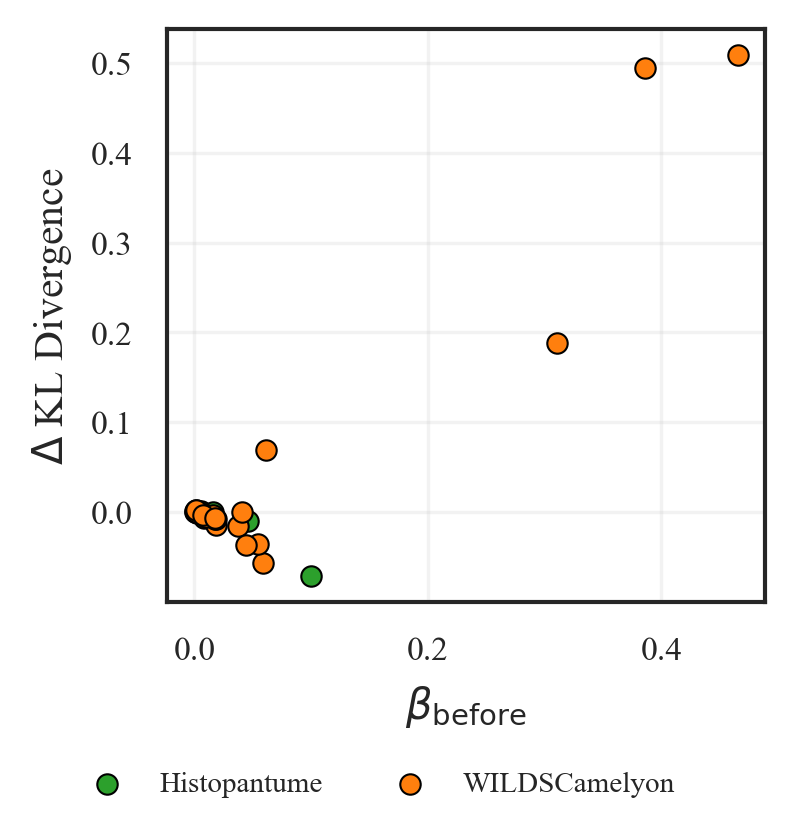

initial_kl_divergence  \
dataset       train_env_names                    test_env_names severity                          
GliomaMRI     erasmus, tcga                      ucsf           -1                     0.127446   
              erasmus, ucsf                      tcga           -1                     0.057794   
              tcga, ucsf                         erasmus        -1                     0.051716   
Histopantume  colon                              ovarian        -1                     0.003279   
                                                 stomach        -1                     0.000096   
                                                 uterus         -1                     0.045784   
              ovarian                            colon          -1                     0.008434   
                                                 stomach        -1                     0.005514   
                                                 uterus         -1                     0.007838   
              stomach                            colon          -1                     0.004503   
                                                 ovarian        -1                     0.015493   
                                                 uterus         -1                     0.099564   
              uterus                             colon          -1                     0.008150   
                                                 ovarian        -1                     0.000081   
                                                 stomach        -1                     0.001406   
MammoBench    cdd-cesm, ddsm, dmid, inbreast     kau-bcmd       -1                     2.185853   
              cdd-cesm, ddsm, dmid, kau-bcmd     inbreast       -1                     0.566468   
              cdd-cesm, ddsm, inbreast, kau-bcmd dmid           -1                     0.230436   
              cdd-cesm, dmid, inbreast, kau-bcmd ddsm           -1                     0.074002   
              ddsm, dmid, inbreast, kau-bcmd     cdd-cesm       -1                     0.143823   
WILDSCamelyon Hospital 1                         Hospital 2     -1                     0.001750   
                                                 Hospital 3     -1                     0.002224   
                                                 Hospital 4     -1                     0.001533   
                                                 Hospital 5     -1                     0.058464   
              Hospital 2                         Hospital 1     -1                     0.054626   
                                                 Hospital 3     -1                     0.386150   
                                                 Hospital 4     -1                     0.018172   
                                                 Hospital 5     -1                     0.465527   
              Hospital 3                         Hospital 1     -1                     0.001625   
                                                 Hospital 2     -1                     0.037377   
                                                 Hospital 4     -1                     0.017715   
                                                 Hospital 5     -1                     0.061238   
              Hospital 4                         Hospital 1     -1                     0.009678   
                                                 Hospital 2     -1                     0.015671   
                                                 Hospital 3     -1                     0.043990   
                                                 Hospital 5     -1                     0.311013   
              Hospital 5                         Hospital 1     -1                     0.007636   
                                                 Hospital 2     -1                     0.040448   
                                                 Hospital 3     -1                     0.018334   
               

In [439]:
import matplotlib.pyplot as plt
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "font.size": 10,
        "font.weight": "normal",
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "legend.fontsize": 7,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "figure.dpi": 300,
    }
)
trivial_score = {
    "ImageNetC": 1 / 1000,
    "WILDSCamelyon": 1 / 2,
    "Histopantume": 1 / 2,
    "MammoBench": 1 / 2,
    "GliomaMRI": 1 / 3
}
def get_delta_potential(row):
    ds = row["dataset"]
    trivial = trivial_score.get(ds, 0)
    initial = row["initial_balanced_accuracy"]
    delta = row["delta_balanced_accuracy"]

    potential_increase = 1 - initial
    potential_decrease = initial - trivial  # floor is trivial, not 0

    if delta >= 0:
        return delta / potential_increase if potential_increase > 0 else 0
    else:
        if potential_decrease <= 0 or delta / potential_decrease < -1:
            # Initial performance was already at or below trivial —
            # any further decrease is unambiguously bad; return -1 as sentinel
            return -1
        return delta / potential_decrease
df["delta_potential"] = df.apply(get_delta_potential, axis=1)
df["delta_kl_divergence"] = df["kl_divergence"] - df["initial_kl_divergence"]
df_pred_bias = df.groupby(["label", "dataset", "train_env_names", "test_env_names", "severity"])[["initial_kl_divergence", "delta_kl_divergence", "kl_divergence", "initial_reverse_kl_divergence", "delta_reverse_kl_divergence", "initial_pred_entropy_orig", "initial_pred_entropy_normalized", "initial_pred_entropy", "delta_balanced_accuracy", "delta_accuracy", "balanced_accuracy", "initial_balanced_accuracy", "delta_roc_auc", "initial_tvd", "tvd", "delta_potential"]].mean().loc["~~$\\bullet~$Tent"]
# df_pred_bias["delta_potential"] = df_pred_bias["delta_potential"] * 100

x_metric = "initial_kl_divergence"
# mask = df_pred_bias.index.get_level_values("dataset") == "WILDSCamelyon"
# df_pred_bias.loc[mask, x_metric] = (
#     df_pred_bias.loc[mask, x_metric] * np.log(2)
# )
# mask = df_pred_bias.index.get_level_values("dataset") == "ImageNetC"
# df_pred_bias.loc[mask, x_metric] = (
#     df_pred_bias.loc[mask, x_metric] * np.log(1000)
# )
# mask = df_pred_bias.index.get_level_values("dataset") == "GliomaMRI"
# df_pred_bias.loc[mask, x_metric] = (
#     df_pred_bias.loc[mask, x_metric] * np.log(3)
# )
# mask = df_pred_bias.index.get_level_values("dataset") == "Histopantume"
# df_pred_bias.loc[mask, x_metric] = (
#     df_pred_bias.loc[mask, x_metric] * np.log(2)
# )
# print(df_pred_bias.loc["ImageNetC","initial_kl_divergence"])

df_pred_bias_plot = df_pred_bias.reset_index()

dataset_colors = {
    "ImageNetC": "tab:blue",
    "WILDSCamelyon": "tab:orange",
    "Histopantume": "tab:green",
    # "MammoBench": "tab:red",
    # "GliomaMRI": "tab:purple"
}

y_col = "delta_kl_divergence"
y_label = "$\Delta$ KL Divergence"
fig, ax = plt.subplots(figsize=(5.5 / 2, 3))
# ax.axhline(y=0, color="gray", linestyle=":", linewidth=1.0, zorder=0)
# ax.axvline(x=0.17, color="gray", linestyle=":", linewidth=1.0, zorder=0)
for (dataset, severity), dataset_df in df_pred_bias_plot.groupby(["dataset", "severity"]):
    if dataset not in dataset_colors.keys():
        continue
    if dataset == "ImageNetC" and severity == 3:
        continue
    # print(dataset_df[["initial_balanced_accuracy", "delta_balanced_accuracy", "potential_increase", "potential_decrease", "delta_potential"]])
    ax.scatter(
        dataset_df[x_metric],
        dataset_df[y_col],
        color=dataset_colors[dataset],
        edgecolors="black",
        linewidths=0.5,
        s=24,
        alpha=1.0,
        label=dataset,
    )

ax.set_xlabel("$\\beta_\\text{before}$")
ax.set_ylabel(y_label)
ax.grid(True, alpha=0.25)
ax.legend(loc="upper center", bbox_to_anchor=(0.35, -0.25), ncol=2, frameon=False)

fig.tight_layout()
plt.show()
fig.savefig("output/pred_bias_correlation.pdf", bbox_inches="tight")

df_pred_bias

MultiIndex([(            'DSBR', 'ResNet'),
            (            'DSBR',    'ViT'),
            (          'ResNet', 'ResNet'),
            (            'Tent', 'ResNet'),
            (            'Tent',    'ViT'),
            (             'ViT',    'ViT'),
            ('~~$\bullet~$DeYO', 'ResNet'),
            ('~~$\bullet~$DeYO',    'ViT'),
            ('~~$\bullet~$ROID', 'ResNet'),
            ('~~$\bullet~$ROID',    'ViT'),
            ( '~~$\bullet~$SAR', 'ResNet'),
            ( '~~$\bullet~$SAR',    'ViT')],
           names=['label', 'model_type'])
Plotting Tent (ResNet50-GN) with color tab:orange and linestyle -
Plotting Tent (ViT-B/16) with color tab:orange and linestyle --
Plotting DSBR (ResNet50-GN) with color tab:purple and linestyle -
Plotting DSBR (ViT-B/16) with color tab:purple and linestyle --


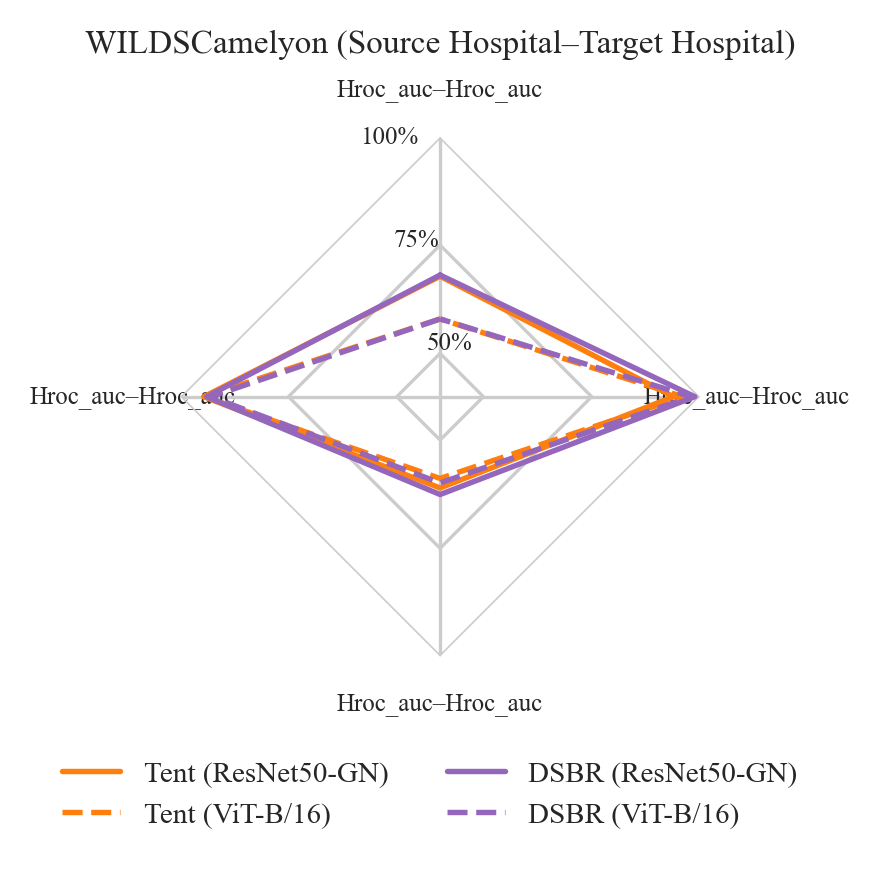

In [440]:
PLOT_RADAR = True
import re
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections import register_projection
from matplotlib.projections.polar import PolarAxes
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D
import seaborn as sns

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "font.size": 8,
        "font.weight": "normal",
        "axes.titlesize": 8,
        "axes.labelsize": 8,
        "legend.fontsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "figure.dpi": 300,
    }
)


def radar_factory(num_vars, frame="polygon"):
    """Create a radar projection with one spoke per variable."""
    theta = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)

    class RadarTransform(PolarAxes.PolarTransform):
        def transform_path_non_affine(self, path):
            if path._interpolation_steps > 1:
                path = path.interpolated(num_vars)
            return Path(self.transform(path.vertices), path.codes)

    class RadarAxes(PolarAxes):
        name = "radar"
        PolarTransform = RadarTransform

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            self.set_theta_zero_location("N")

        def fill(self, *args, closed=True, **kwargs):
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)
            return lines

        def _close_line(self, line):
            x, y = line.get_data()
            if x[0] != x[-1]:
                x = np.append(x, x[0])
                y = np.append(y, y[0])
                line.set_data(x, y)

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
            if frame == "circle":
                return Circle((0.5, 0.5), 0.5)
            if frame == "polygon":
                return RegularPolygon((0.5, 0.5), num_vars, radius=0.5, edgecolor="none")
            raise ValueError(f"Unknown value for frame: {frame}")

        def _gen_axes_spines(self):
            if frame == "circle":
                return super()._gen_axes_spines()
            if frame == "polygon":
                spine = Spine(axes=self, spine_type="circle", path=Path.unit_regular_polygon(num_vars))
                spine.set_transform(Affine2D().scale(0.5).translate(0.5, 0.5) + self.transAxes)
                return {"polar": spine}
            raise ValueError(f"Unknown value for frame: {frame}")

    register_projection(RadarAxes)
    return theta


def format_spoke_label(col):
    if isinstance(col, tuple):
        col = col[3:]
        left = str(col[0]).replace("Hospital ", "")
        right_source = col[1] if len(col) > 1 and str(col[1]).strip() else col[0]
        right = str(right_source).replace("Hospital ", "")
        return f"H{left}–H{right}"
    return str(col).replace("Hospital ", "H")


drop_cols = [col for col in mean_df.columns if col[-1].lower().startswith("avg") or col[-1].lower().startswith("delta") or "_std" in col[-1].lower() or col[-2] == col[-3]]
radar_df = mean_df.drop(columns=drop_cols, errors="ignore").reorder_levels(["label", "model_type"], axis=0)
for label in radar_df.index.get_level_values("label"):
    if "DSBR" in label:
        radar_df.rename(index={label: "DSBR"}, inplace=True)
    if "Tent" in label:
        radar_df.rename(index={label: "Tent"}, inplace=True)  
radar_df.sort_index(inplace=True, ascending=True) 
print(radar_df.index)      
spoke_labels = [format_spoke_label(col) for col in radar_df.columns]
theta = radar_factory(len(spoke_labels), frame="polygon")

fig, ax = plt.subplots(figsize=(5.5 /2, 5.5 / 2), subplot_kw={"projection": "radar"})
ax.patch.set_edgecolor((0, 0, 0, 0))
ax.spines["polar"].set_edgecolor((0, 0, 0, 0))
ax.spines["polar"].set_linewidth(0.0)

r_min, r_max = 40, 100
ax.set_ylim(r_min, r_max)
grid_values = [50, 75, 100]
grid_labels = [f"{v:.0f}%" for v in grid_values]
ax.set_rgrids(grid_values, labels=grid_labels, angle=18)
ax.set_varlabels(spoke_labels)
ax.tick_params(axis="x", pad=-0.5)

model_colors = {
    "Tent": "tab:orange",
    "DSBR": "tab:purple",
}
models = [
    "Tent",
    "DSBR",
]
radar_df = radar_df.loc[models]
for row_idx, row_values in radar_df.iterrows():
    values = np.nan_to_num(row_values.to_numpy(dtype=float), nan=0.0)
    # print(values)
    label, model_type  = row_idx
    model_type = model_type.replace("ViT", "ViT-B/16").replace("ResNet", "ResNet50-GN")
    row_label = f"{label} ({model_type})"
    row_color = model_colors.get(label, "black")
    row_linestyle = "--" if "ViT" in model_type else "-"
    print(f"Plotting {row_label} with color {row_color} and linestyle {row_linestyle}"  )
    ax.plot(theta, values*100, color=row_color, linestyle=row_linestyle, linewidth=1.3, label=row_label)
    # ax.fill(theta, values*100, color=row_color, alpha=0.1)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=2, frameon=False)
ax.set_title("WILDSCamelyon (Source Hospital–Target Hospital)")
fig.subplots_adjust(bottom=0.25)
plt.savefig("radar_plot.png", bbox_inches="tight")
plt.show()

In [441]:
selected_metrics

['roc_auc', 'delta_roc_auc']

<>:133: SyntaxWarning: invalid escape sequence '\D'
<>:133: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1207231/3811389744.py:133: SyntaxWarning: invalid escape sequence '\D'
  axes[0].set_ylabel("$\Delta$ Accuracy (%)")


ValueError: Unknown dataset: GliomaMRI

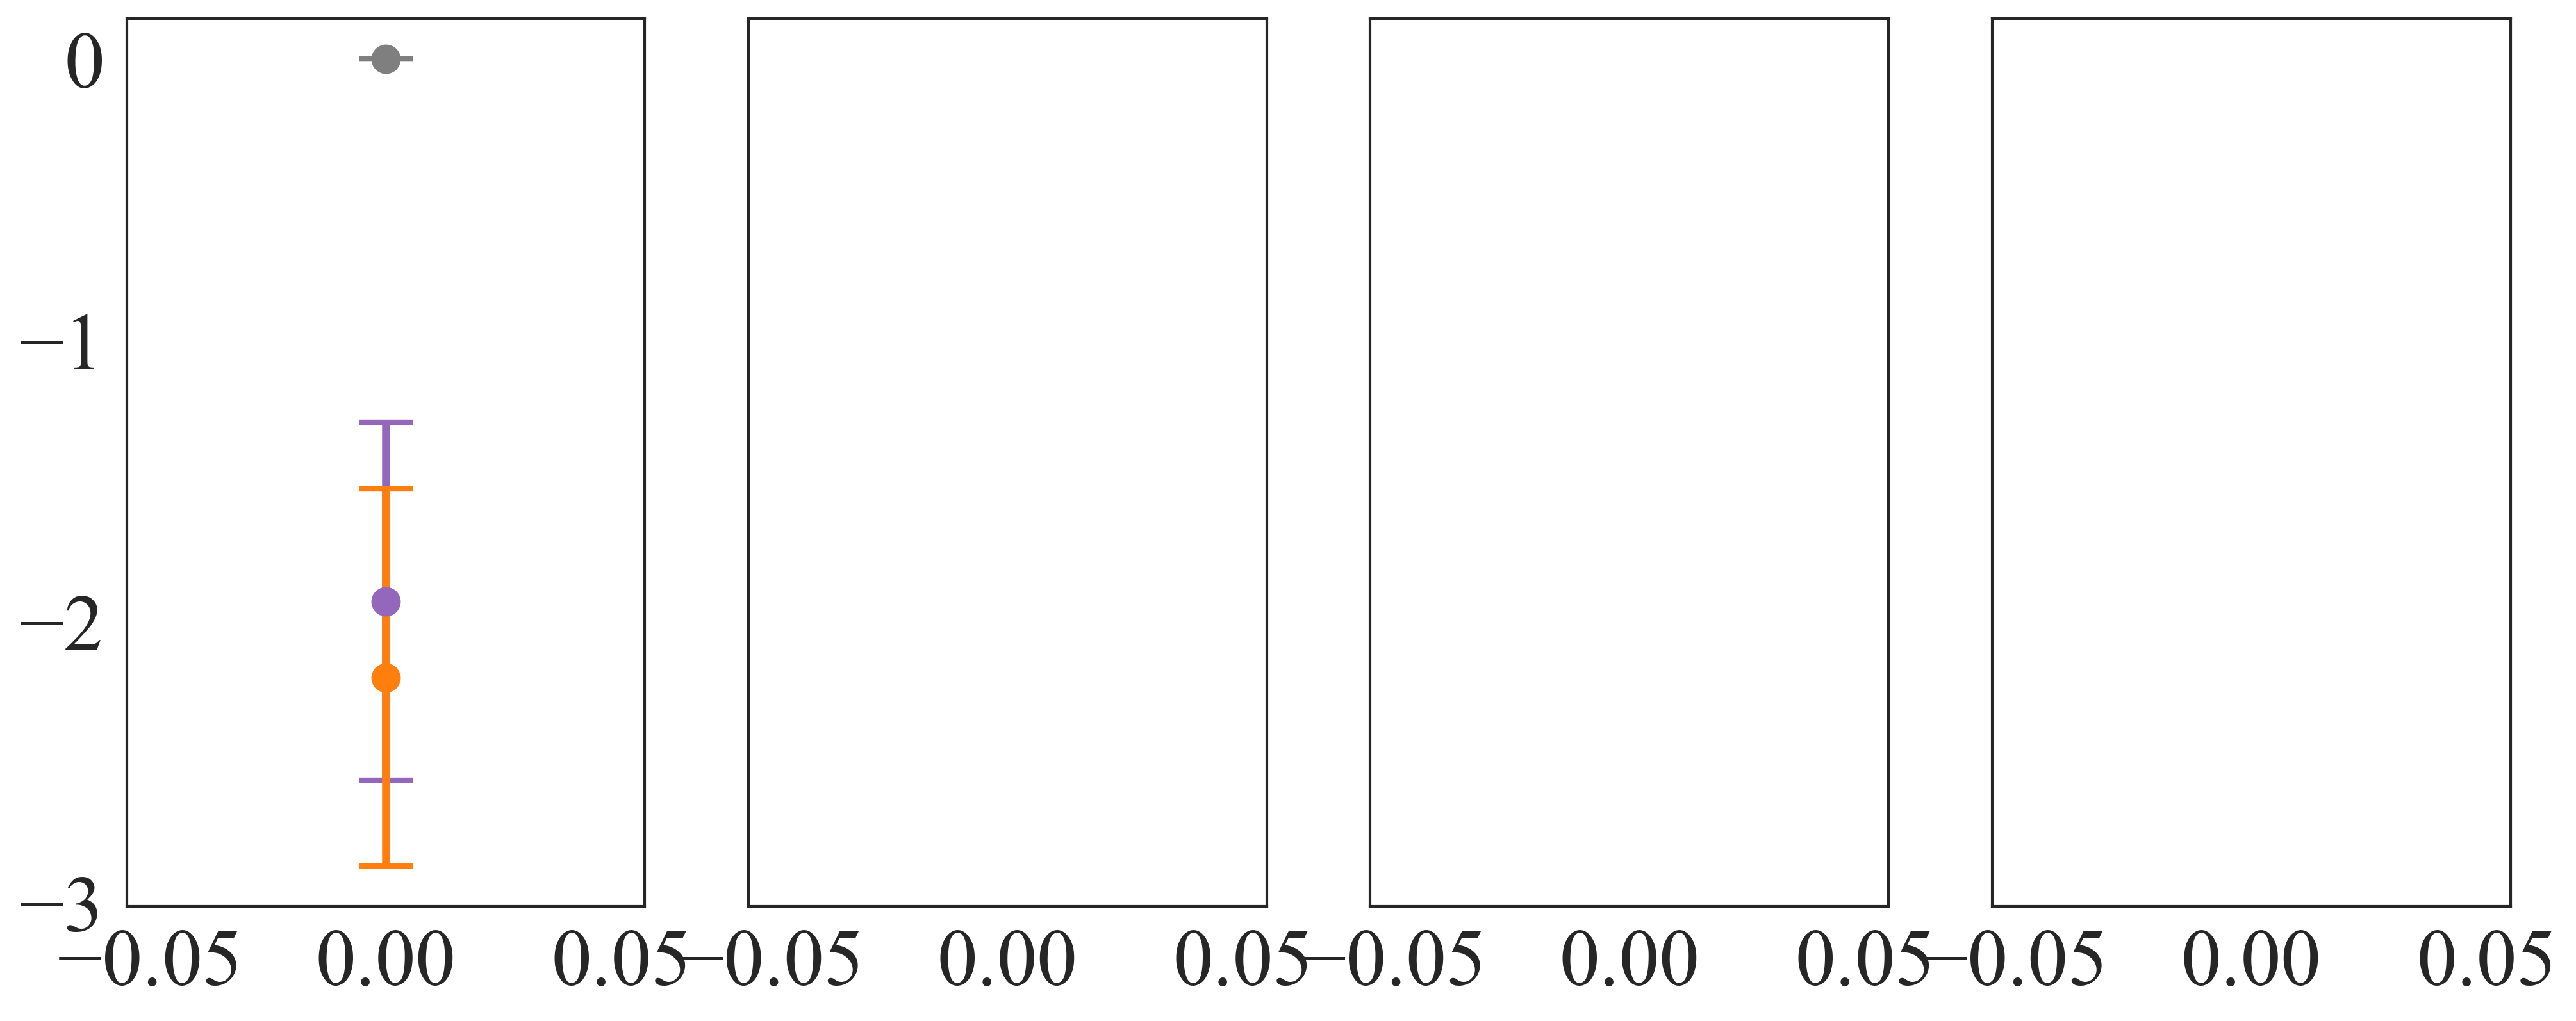

In [442]:
model_type = "ResNet"
sns.set_theme("paper", "white")
selected_metric = f"delta_{selected_metrics[0]}"
plot_table = mean_df.loc[model_type]
filter = ["Tent", "$\\alpha=0.9$", "$\\alpha=0.0$", "ResNet"]
filtered_index = [i for i in plot_table.index if any(f in i for f in filter)]
plot_table = plot_table.loc[filtered_index]
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "font.size": 30,
        "font.weight": "normal",
        "axes.titlesize": 30,
        "axes.labelsize": 30,
        "legend.fontsize": 25,
        "xtick.labelsize": 30,
        "ytick.labelsize": 30,
        "figure.dpi": 300,
    }
)

def clean_label(label):
    if "DSBR" in label:
        if "0.99" in label:
            return "DSBR($\\alpha=0.99$)"
        elif "0.95" in label:
            return "DSBR($\\alpha=0.95$)"
        elif "0.9" in label:
            return "DSBR($\\alpha=0.9$)"
        else:
            return "DSBR($\\alpha=0.0$)"
    if "Tent" in label:
        return "Tent"
    if "ResNet" in label:
        return "ResNet50-GN"
    if "ViT" in label:
        return "ViT-B16"
    return str(label)

def get_algorithm_name(label):
    cleaned = clean_label(label)
    return re.split(r"[+(]", cleaned, maxsplit=1)[0].strip()

def get_line_style(label):
    cleaned = clean_label(label)
    if "alpha=0.99" in cleaned:
        return "-."
    elif "alpha=0.95" in cleaned:
        return ":"
    elif "alpha=0.9" in cleaned:
        return "-"
    elif "alpha=0.0" in cleaned:
        return "--"

def normalize_dataset_table(dataset_table):
    if isinstance(dataset_table.columns, pd.MultiIndex):
        # Keep only batch_size as plotting x-axis and aggregate across remaining levels.
        dataset_table = dataset_table.copy()
        dataset_table.columns = [col[0] if isinstance(col, tuple) else col for col in dataset_table.columns]
        dataset_table = dataset_table.T.groupby(level=0).mean().T
    return dataset_table

algorithm_names = [get_algorithm_name(label) for label in plot_table.index]
unique_algorithm_names = list(dict.fromkeys(algorithm_names))
# palette = sns.color_palette("tab10", n_colors=max(1, len(unique_algorithm_names)))
# algorithm_colors = {name: palette[i % len(palette)] for i, name in enumerate(unique_algorithm_names)}
algorithm_colors = {
    "DSBR": "tab:purple",
    "Tent": "tab:orange",
    "ResNet50-GN": "tab:gray",
}

datasets_sorted = sorted(datasets)
batch_sizes_sorted = sorted(batch_sizes)

n_datasets = len(datasets_sorted)
fig, axes = plt.subplots(1, n_datasets, figsize=(16, 6), sharex=True, sharey=True)
if n_datasets == 1:
    axes = [axes]

legend_specs = {}
for i, (ax, dataset) in enumerate(zip(axes, datasets_sorted)):
    # if dataset=="WILDSCamelyon":
    #     continue
    dataset_table = plot_table.xs((dataset, selected_metric), level=("dataset", "metric"), axis=1)
    dataset_table = normalize_dataset_table(dataset_table)

    std_metric = f"{selected_metric}_std"
    dataset_table_std = plot_table.xs((dataset, std_metric), level=("dataset", "metric"), axis=1)
    dataset_table_std = normalize_dataset_table(dataset_table_std)

    my_batch_sizes = [b for b in batch_sizes_sorted if b in dataset_table.columns]
    dataset_table = dataset_table.reindex(columns=my_batch_sizes)
    dataset_table_std = dataset_table_std.reindex(columns=my_batch_sizes)

    for label_name, row in dataset_table.iterrows():
        clean = clean_label(label_name)
        algorithm_name = get_algorithm_name(label_name)
        line_color = algorithm_colors[algorithm_name]
        line_style = get_line_style(label_name)
        row_std = dataset_table_std.loc[label_name]

        x_positions = np.arange(len(my_batch_sizes))
        ax.errorbar(
            x_positions,
            100 * row.to_numpy(dtype=float),
            yerr=100 * row_std.to_numpy(dtype=float),
            color=line_color,
            linestyle=line_style,
            linewidth=5,
            marker="o",
            markersize=10,
            capsize=10,
            capthick=2,
            elinewidth=3,
        )

        legend_specs[clean] = (line_color, line_style)
    if dataset == "WILDSCamelyon":
        ax.set_title(f"WILDSCamelyon (Hospital Nr. 2 → 5)")
    elif dataset == "ImageNetC":
        ax.set_title("ImageNetC (Gauss. Noise, Severity 5)")
    else:
        raise ValueError(f"Unknown dataset: {dataset}")
    # if i == n_datasets - 1:
    ax.set_xlabel("Batch size")
    x_positions = np.arange(len(my_batch_sizes))
    ax.set_xticks(x_positions)
    ax.set_xticklabels([str(int(b)) for b in my_batch_sizes])
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("$\Delta$ Accuracy (%)")

legend_order = [clean_label(label) for label in plot_table.index]
legend_order = list(dict.fromkeys(legend_order))
legend_handles = [
    plt.Line2D(
        [0],
        [0],
        color=legend_specs[label][0],
        linestyle=legend_specs[label][1],
        linewidth=5,
        marker="o",
        markersize=4,
        label=label,
    )
    for label in legend_order
    if label in legend_specs
]

# fig.suptitle(f"{clean_label(model_type)} - {selected_metric.replace('_', ' ')}")
fig.legend(
    handles=legend_handles,
    labels=[h.get_label() for h in legend_handles],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.07),
    ncol=min(4, max(1, len(legend_handles))),
    frameon=False,
    handlelength=3.0,
    columnspacing=1.2,
    handletextpad=0.6,
    borderaxespad=0.2,
    fancybox=False,
    shadow=False,
    markerfirst=True,
    alignment="center",
)

fig.tight_layout()
import os
os.makedirs("output/ablation", exist_ok=True)
fig.savefig(f"output/ablation/batch_size_subplots_{clean_label(model_type)}_{selected_metric}.pdf", bbox_inches="tight")
plt.show()
